In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils
import glob
from scipy.optimize import curve_fit
from scipy import special

In [2]:
sns.set_palette("viridis")

In [12]:
#select colors from sns palette
colors = sns.color_palette("viridis", n_colors=10)
print(colors)

[(0.283072, 0.130895, 0.449241), (0.262138, 0.242286, 0.520837), (0.220057, 0.343307, 0.549413), (0.177423, 0.437527, 0.557565), (0.143343, 0.522773, 0.556295), (0.119512, 0.607464, 0.540218), (0.166383, 0.690856, 0.496502), (0.319809, 0.770914, 0.411152), (0.525776, 0.833491, 0.288127), (0.762373, 0.876424, 0.137064)]


In [13]:
temperatures = [-40,-30, -20,-10, 0]

In [14]:
devices = ['LMG405', 'LMG450', 'LMG365', 'LMG520', 'KAPU465', 'KAPU405']

In [15]:
device = 'LMG405'
pw = 54000
coarse_fine = '2-20'
mode = 'default'
batch = 'batch2'
pocam = 26
hemisphere = 52

In [16]:
def gaussian(x, mean, sigma):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


def skewing_erf(x, mean, sigma, alpha):
    return 0.5 * (1 + special.erf(alpha * (x - mean) / (np.sqrt(2) * sigma)))


def skewed_gaussian(x, mean, sigma, scaling, alpha):
    """Skewed Gaussian: scaled pdf of a skew-normal distribution."""
    return scaling * 2 * gaussian(x, mean, sigma) * skewing_erf(x, mean, sigma, alpha)

def skewed_double_gaussian(x, mean, sigma, scaling, alpha,
                           mean_2, sigma_2, scaling_2):
    """Skewed Gaussian main peak + plain Gaussian secondary peak."""
    return (skewed_gaussian(x, mean, sigma, scaling, alpha)
            + scaling_2 * gaussian(x, mean_2, sigma_2))

In [17]:
coarse_fine = ['1-10', '1-20', '1-40', '2-20']

In [18]:
T = -20

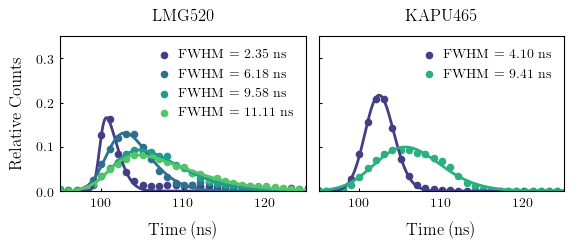

In [19]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=plot_utils.set_size('text', fraction=1, subplots=(1,2)), sharey = True)
device1 = "LMG520"
for c_f, color in zip(coarse_fine, [colors[1], colors[3], colors[5], colors[7]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device1}/tdc_{pw:.0f}_{T}C_{c_f}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    fwhm = data['meas_data'][1]['value']
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    #fit a skewed gaussian to the data in the x-fit range
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] -100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, data['meas_data'][0]['y_values'], p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(data['meas_data'][0]['y_values']), 0])
    #plot fit and data
    ax1.scatter(x_values-offset_data, data['meas_data'][0]['y_values'],s= 20,color = color, label = f'FWHM = {fwhm:.2f} ns')
    # ax.step(x_values-offset_data, data['meas_data'][0]['y_values'], where ='mid',label = f'{c_f}')
    ax1.plot(x_fit, skewed_gaussian(x_fit, *fit), color= color)
    # plt.plot(x_fit-offset_fit, data['meas_data'][0]['fit_y_values'])

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Relative Counts')
ax1.set_xlim(95,125)
ax1.set_ylim(0,0.35)
ax1.legend()
ax1.set_title(f'{device1}', size = 12, y = 1.2)
device2 = "KAPU465"
for mode, color in zip(['fast','default'], [colors[1], colors[6]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device2}/tdc_{pw:.0f}_{T}C_{mode}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    fwhm = data['meas_data'][1]['value']
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    #fit a skewed gaussian to the data in the x-fit range
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] -100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, data['meas_data'][0]['y_values'], p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(data['meas_data'][0]['y_values']), 0])
    #plot fit and data
    ax2.scatter(x_values-offset_data, data['meas_data'][0]['y_values'],s= 20,color = color, label = f'FWHM = {fwhm:.2f} ns')
    # ax.step(x_values-offset_data, data['meas_data'][0]['y_values'], where ='mid',label = f'{c_f}')
    ax2.plot(x_fit, skewed_gaussian(x_fit, *fit), color = color)

ax2.set_xlabel('Time (ns)')
ax2.set_xlim(95,125)
ax2.legend()
ax2.set_title(f'{device2}', size = 12, y = 1.2)
plt.subplots_adjust(wspace=0.05)
plt.savefig(f'plots/png/{device1}_{device2}_pocam_{pocam}_hem_{hemisphere}_tdc_{pw:.0f}_{T}C_skewed_gaussian_fit.png', dpi=300)

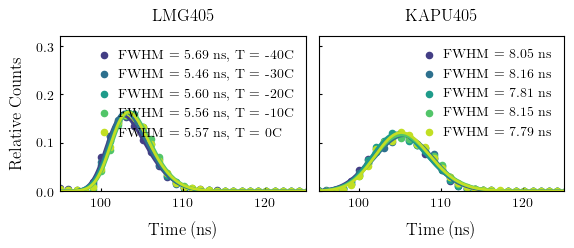

In [20]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=plot_utils.set_size('text', fraction=1, subplots=(1,2)), sharey = True)
device1 = "LMG405"
c_f = '1-20'
temperatures = [-40,-30, -20,-10, 0]
for T, color in zip(temperatures, [colors[1], colors[3], colors[5], colors[7], colors[9]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device1}/tdc_{pw:.0f}_{T}C_{c_f}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    fwhm = data['meas_data'][1]['value']
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    #fit a skewed gaussian to the data in the x-fit range
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] -100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, data['meas_data'][0]['y_values'], p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(data['meas_data'][0]['y_values']), 0])
    #plot fit and data
    ax1.scatter(x_values-offset_data, data['meas_data'][0]['y_values'],s= 20,color = color, label = f'FWHM = {fwhm:.2f} ns, T = {T}C')
    # ax.step(x_values-offset_data, data['meas_data'][0]['y_values'], where ='mid',label = f'{c_f}')
    ax1.plot(x_fit, skewed_gaussian(x_fit, *fit), color= color)
    # plt.plot(x_fit-offset_fit, data['meas_data'][0]['fit_y_values'])

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Relative Counts')
ax1.set_xlim(95,125)
ax1.set_ylim(0,0.32)
ax1.legend()
ax1.set_title(f'{device1}', size = 12, y = 1.2)

device2 = "KAPU405"
mode = 'default'
for T, color in zip(temperatures, [colors[1], colors[3], colors[5], colors[7], colors[9]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device2}/tdc_{pw:.0f}_{T}C_{mode}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    fwhm = data['meas_data'][1]['value']
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    #fit a skewed gaussian to the data in the x-fit range
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] -100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, data['meas_data'][0]['y_values'], p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(data['meas_data'][0]['y_values']), 0])
    #plot fit and data
    ax2.scatter(x_values-offset_data, data['meas_data'][0]['y_values'],s= 20,color = color, label = f'FWHM = {fwhm:.2f} ns')
    # ax.step(x_values-offset_data, data['meas_data'][0]['y_values'], where ='mid',label = f'{c_f}')
    ax2.plot(x_fit, skewed_gaussian(x_fit, *fit), color = color)

ax2.set_xlabel('Time (ns)')
ax2.set_xlim(95,125)
ax2.legend()
ax2.set_title(f'{device2}', size = 12, y = 1.2)
plt.subplots_adjust(wspace=0.05)
plt.savefig(f'plots/png/{device1}_{device2}_pocam_{pocam}_hem_{hemisphere}_tdc_{pw:.0f}_check_Temperatures_skewed_gaussian_fit.png', dpi=300)

In [23]:
devices = ['LMG365', 'LMG405', 'LMG450', 'LMG520', 'KAPU405', 'KAPU465']


In [27]:
Temperatures = [-40,-30, -20, -10, 0, 25]

0
1
2
3
4
5


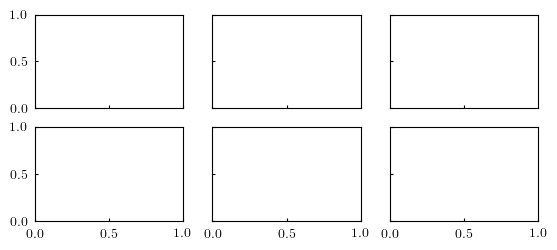

In [22]:
fig, axes = plt.subplots(2,3, figsize=plot_utils.set_size('text', fraction=1, subplots=(2,3)), sharex = True, sharey = True)

for i, ax in enumerate(axes.flat):
    device = devices[i]
    for T in Temperatures:
        files = glob.glob(f'../output/batch*/pocam_*/hem_*/{device}/tdc_{pw:.0f}_{T}C_*.json')